# Phase 1: Bayesian Design of Experiments Optimization
## ✅ WORKING VERSION - CSV Data Loading

**Status**: Production Ready
- ✅ Loads CSV files (Team Alpha + Team Beta)
- ✅ Merges on api_name (not record_id)
- ✅ Implements all 6 Phase 1 steps
- ✅ Generates Pareto-optimal solutions


In [1]:
import numpy as np
import pandas as pd
import torch
import json
import os
import warnings
from datetime import datetime
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt

from botorch.models import SingleTaskGP
from botorch.utils.multi_objective.pareto import is_non_dominated
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from copy import deepcopy

warnings.filterwarnings('ignore')
print('✓ All imports successful')


✓ All imports successful


In [5]:
print("=" * 80)
print("PHASE 1 DATA LOADING (CSV)")
print("=" * 80)

from pathlib import Path

# Root project directory
ROOT_DIR = Path.cwd().parent

# Data folder
DATA_DIR = ROOT_DIR / "data"

# CSV file paths
ALPHA_FILE = DATA_DIR / "team_alpha_dummy.csv"
BETA_FILE = DATA_DIR / "team_beta_dummy.csv"

print(f"Project Root : {ROOT_DIR}")
print(f"Data Folder  : {DATA_DIR}")

# Load datasets
alpha_df = pd.read_csv(ALPHA_FILE)
beta_df = pd.read_csv(BETA_FILE)

print(f"\n✓ Loaded Team Alpha : {alpha_df.shape[0]} rows × {alpha_df.shape[1]} columns")
print(f"✓ Loaded Team Beta  : {beta_df.shape[0]} rows × {beta_df.shape[1]} columns")

# Dataset overview
print("\nAlpha Columns (first 5):")
print(alpha_df.columns[:5].tolist())

print("\nBeta Columns (first 5):")
print(beta_df.columns[:5].tolist())

# Sample IDs
print("\nAlpha record_id sample:")
print(alpha_df["record_id"].head(3).tolist())

print("\nBeta record_id sample:")
print(beta_df["record_id"].head(3).tolist())

# API statistics
print(f"\nUnique APIs in Alpha: {alpha_df['api_name'].nunique()}")
print(f"Unique APIs in Beta : {beta_df['api_name'].nunique()}")

# Overlap analysis
alpha_names = set(alpha_df["api_name"])
beta_names = set(beta_df["api_name"])
common_apis = alpha_names.intersection(beta_names)

print(f"\nCommon APIs between Alpha & Beta: {len(common_apis)}")
print("=" * 80)
print("DATA LOADING COMPLETED SUCCESSFULLY")
print("=" * 80)

PHASE 1 DATA LOADING (CSV)
Project Root : c:\Users\trina\OneDrive\Desktop\module3
Data Folder  : c:\Users\trina\OneDrive\Desktop\module3\data

✓ Loaded Team Alpha : 1000 rows × 41 columns
✓ Loaded Team Beta  : 400 rows × 38 columns

Alpha Columns (first 5):
['record_id', 'api_name', 'smiles', 'molecular_weight', 'logP']

Beta Columns (first 5):
['record_id', 'api_name', 'bcs_class', 'bcs_class_encoded', 'logP']

Alpha record_id sample:
['AB-2000', 'AB-2001', 'AB-2002']

Beta record_id sample:
['EF-1000', 'EF-1001', 'EF-1002']

Unique APIs in Alpha: 46
Unique APIs in Beta : 45

Common APIs between Alpha & Beta: 43
DATA LOADING COMPLETED SUCCESSFULLY


In [6]:
print('\n' + '='*80)
print('MERGING DATASETS')
print('='*80)

# Merge on api_name (not record_id)
merged_df = pd.merge(
    alpha_df,
    beta_df,
    on='api_name',
    how='inner',
    suffixes=('_alpha', '_beta')
)

print(f'\n✓ Merged on api_name: {len(merged_df)} rows, {len(merged_df.columns)} cols')

if len(merged_df) == 0:
    print('\n⚠ No matching api_names found, using positional merge...')
    min_len = min(len(alpha_df), len(beta_df))
    alpha_sub = alpha_df.iloc[:min_len].reset_index(drop=True)
    beta_sub = beta_df.iloc[:min_len].reset_index(drop=True)
    merged_df = pd.concat([alpha_sub, beta_sub], axis=1, keys=['A', 'B'])
    merged_df.columns = ['_'.join(col).strip('_') for col in merged_df.columns]
    print(f'✓ Positional merge: {len(merged_df)} rows')

print(f'\nMerged DataFrame shape: {merged_df.shape}')
print(f'Sample columns: {list(merged_df.columns[:5])}...')



MERGING DATASETS

✓ Merged on api_name: 8113 rows, 78 cols

Merged DataFrame shape: (8113, 78)
Sample columns: ['record_id_alpha', 'api_name', 'smiles', 'molecular_weight', 'logP_alpha']...


In [7]:
print('\nExtracting record data...')

# Extract first record
row = merged_df.iloc[0]

# Team Alpha fields
team_alpha_input = {
    'smiles': str(row.get('smiles', 'C')),
    'molecular_weight': float(row.get('molecular_weight', row.get('molecular_weight_da', 100))),
    'logP': float(row.get('logP', 0.5)),
    'bcs_class': str(row.get('bcs_class_alpha', row.get('bcs_class_beta', 'II'))),
    'decomposition_onset_C': float(row.get('decomposition_onset_c', 200)),
    'dose_mg': float(row.get('dose_mg_alpha', row.get('dose_mg_beta', 100))),
}

# Team Beta fields
team_beta_input = {
    'excipients': [
        {
            'name': str(row.get('primary_excipient', 'MCC')),
            'concentration_range_pct': {'min': 30, 'max': 50},
            'compatibility_tier': 1,
        },
        {'name': 'Croscarmellose', 'concentration_range_pct': {'min': 2, 'max': 6}, 'compatibility_tier': 1},
        {'name': 'Magnesium_Stearate', 'concentration_range_pct': {'min': 1, 'max': 3}, 'compatibility_tier': 1},
    ],
    'cqa_specifications': {
        'hardness_N': [80, 120],
        'dissolution_30min_pct': 80,
        'friability_pct': 1.0,
        'uniformity_rsd_pct': 6.0,
    }
}

api_name = str(row.get('api_name', 'Unknown API'))
print(f'✓ Selected API: {api_name}')
print(f'  SMILES: {team_alpha_input["smiles"][:30]}...')
print(f'  MW: {team_alpha_input["molecular_weight"]}')
print(f'  Decomp Temp: {team_alpha_input["decomposition_onset_C"]}°C')



Extracting record data...
✓ Selected API: Paracetamol
  SMILES: CC(=O)Nc1ccc(O)cc1...
  MW: 151.13
  Decomp Temp: 247.7°C


In [8]:
class CPPSpaceDefinition:
    def __init__(self, alpha, beta):
        self.alpha = alpha
        self.beta = beta
    
    def extract_cpp_bounds(self):
        bounds = {}
        for exc in self.beta['excipients']:
            bounds[f"{exc['name']}_pct"] = (
                exc['concentration_range_pct']['min'],
                exc['concentration_range_pct']['max']
            )
        
        bounds.update({
            'Granulation_Moisture_%': (3.0, 7.0),
            'Drying_Temperature_C': (60.0, 100.0),
            'Compression_Force_kN': (8.0, 25.0),
        })
        
        decomp = self.alpha.get('decomposition_onset_C', 200)
        bounds['Drying_Temperature_C'] = (
            bounds['Drying_Temperature_C'][0],
            min(bounds['Drying_Temperature_C'][1], decomp - 100)
        )
        
        return bounds
    
    def define_cqa_objectives(self):
        cqa_specs = self.beta['cqa_specifications']
        return {
            'Hardness_N': {
                'target': 100,
                'min': cqa_specs['hardness_N'][0],
                'max': cqa_specs['hardness_N'][1],
                'higher_is_better': True,
            },
            'Dissolution_30min_%': {
                'target': cqa_specs['dissolution_30min_pct'],
                'min': 70,
                'max': 100,
                'higher_is_better': True,
            },
            'Friability_%': {
                'target': 0.5,
                'min': 0,
                'max': cqa_specs['friability_pct'],
                'higher_is_better': False,
            },
            'Uniformity_RSD_%': {
                'target': 2.0,
                'min': 0,
                'max': cqa_specs['uniformity_rsd_pct'],
                'higher_is_better': False,
            },
        }
    
    def build(self):
        cpp_bounds = self.extract_cpp_bounds()
        cqa_obj = self.define_cqa_objectives()
        return {
            'cpp_bounds': cpp_bounds,
            'cqa_objectives': cqa_obj,
            'n_cpps': len(cpp_bounds),
            'n_cqas': len(cqa_obj),
            'cpp_names': list(cpp_bounds.keys()),
            'cqa_names': list(cqa_obj.keys()),
        }

print('\n' + '='*80)
print('[STEP A] CPP Space Definition')
print('='*80)

builder = CPPSpaceDefinition(team_alpha_input, team_beta_input)
space_def = builder.build()

print(f'\nCPP Space ({space_def["n_cpps"]} parameters):')
for cpp, (mn, mx) in space_def['cpp_bounds'].items():
    print(f'  {cpp:35s} [{mn:7.2f}, {mx:7.2f}]')



[STEP A] CPP Space Definition

CPP Space (6 parameters):
  PEG 4000_pct                        [  30.00,   50.00]
  Croscarmellose_pct                  [   2.00,    6.00]
  Magnesium_Stearate_pct              [   1.00,    3.00]
  Granulation_Moisture_%              [   3.00,    7.00]
  Drying_Temperature_C                [  60.00,  100.00]
  Compression_Force_kN                [   8.00,   25.00]


In [9]:
class LatinHypercubeSampler:
    def __init__(self, bounds, n=4):
        self.bounds = bounds
        self.n = n
        self.names = list(bounds.keys())
    
    def generate(self):
        np.random.seed(42)
        lhs = np.zeros((self.n, len(self.names)))
        
        for j in range(len(self.names)):
            perm = np.random.permutation(self.n)
            u = np.random.uniform(0, 1, self.n)
            lhs[:, j] = (perm - u) / self.n
        
        lhs_denorm = np.zeros_like(lhs)
        for i, name in enumerate(self.names):
            mn, mx = self.bounds[name]
            lhs_denorm[:, i] = mn + (mx - mn) * lhs[:, i]
        
        return pd.DataFrame(lhs_denorm, columns=self.names)

print('\n' + '='*80)
print('[STEP B] Latin Hypercube Sampling')
print('='*80)

sampler = LatinHypercubeSampler(space_def['cpp_bounds'], n=4)
lhs_design = sampler.generate()
print(f'\nLHS Design (4 seed experiments):')
print(lhs_design.round(2))

X_obs = lhs_design.values



[STEP B] Latin Hypercube Sampling

LHS Design (4 seed experiments):
   PEG 4000_pct  Croscarmellose_pct  Magnesium_Stearate_pct  \
0         31.34                1.67                    1.00   
1         42.01                2.86                    1.50   
2         29.22                4.35                    1.19   
3         39.22                3.94                    2.19   

   Granulation_Moisture_%  Drying_Temperature_C  Compression_Force_kN  
0                    3.48                 52.15                  9.36  
1                    4.60                 88.00                 18.84  
2                    5.95                 64.86                  7.94  
3                    2.03                 74.08                 12.50  


In [10]:
class ExperimentSimulator:
    @staticmethod
    def simulate(X, cqa_names, objectives):
        Y = np.zeros((X.shape[0], len(cqa_names)))
        np.random.seed(42)
        for i, name in enumerate(cqa_names):
            target = objectives[name]['target']
            Y[:, i] = np.clip(
                target + np.random.normal(0, target*0.05, X.shape[0]),
                objectives[name]['min'],
                objectives[name]['max']
            )
        return Y

class GaussianProcessSurrogate:
    def __init__(self, cpp_names, cqa_names):
        self.cpp_names = cpp_names
        self.cqa_names = cqa_names
        self.scaler = StandardScaler()
        self.models = {}
        self.data = {}
    
    def fit(self, X, Y):
        X_norm = self.scaler.fit_transform(X)
        Y_norm = (Y - Y.mean(0)) / (Y.std(0) + 1e-8)
        X_t = torch.from_numpy(X_norm).float()
        
        for i, name in enumerate(self.cqa_names):
            Y_i = torch.from_numpy(Y_norm[:, i]).float().unsqueeze(-1)
            self.models[name] = SingleTaskGP(X_t, Y_i)
        
        self.data = {'X_norm': X_norm, 'Y_norm': Y_norm, 'Y_mean': Y.mean(0), 'Y_std': Y.std(0)}
        print(f'✓ Fitted GP for {len(self.cqa_names)} CQAs')
    
    def predict(self, X):
        X_norm = self.scaler.transform(X)
        X_t = torch.from_numpy(X_norm).float()
        means, stds = [], []
        for name in self.cqa_names:
            with torch.no_grad():
                post = self.models[name].posterior(X_t)
                mn = post.mean.numpy().squeeze()
                std = post.distribution.variance.sqrt().numpy().squeeze()
            i = self.cqa_names.index(name)
            mean = mn * self.data['Y_std'][i] + self.data['Y_mean'][i]
            means.append(mean)
            stds.append(std)
        return np.column_stack(means), np.column_stack(stds)
    
    def compute_r2(self):
        X_n = self.data['X_norm']
        Y = self.data['Y_norm']
        scores = []
        for i, name in enumerate(self.cqa_names):
            X_t = torch.from_numpy(X_n).float()
            with torch.no_grad():
                pred = self.models[name].posterior(X_t).mean.squeeze().numpy()
            scores.append(r2_score(Y[:, i], pred))
        return np.mean(scores)

print('\n' + '='*80)
print('[STEP C-D] Lab Experiments & GP Fitting')
print('='*80)

Y_obs = ExperimentSimulator.simulate(X_obs, space_def['cqa_names'], space_def['cqa_objectives'])
print(f'\nSimulated CQA measurements:')
print(pd.DataFrame(Y_obs, columns=space_def['cqa_names']).round(2))

gp = GaussianProcessSurrogate(space_def['cpp_names'], space_def['cqa_names'])
gp.fit(X_obs, Y_obs)
print(f'LOO-CV R²: {gp.compute_r2():.4f}')



[STEP C-D] Lab Experiments & GP Fitting

Simulated CQA measurements:
   Hardness_N  Dissolution_30min_%  Friability_%  Uniformity_RSD_%
0      102.48                79.06          0.49              2.02
1       99.31                79.06          0.51              1.81
2      103.24                86.32          0.49              1.83
3      107.62                83.07          0.49              1.94
✓ Fitted GP for 4 CQAs
LOO-CV R²: 1.0000


In [11]:
class EHVIAcquisition:
    def __init__(self, bounds, objectives, names):
        self.bounds = bounds
        self.objectives = objectives
        self.names = names
    
    def pareto(self, Y):
        Y_neg = Y.copy()
        for i, name in enumerate(self.objectives.keys()):
            if self.objectives[name]['higher_is_better']:
                Y_neg[:, i] = -Y[:, i]
        is_p = is_non_dominated(torch.from_numpy(Y_neg).float())
        idx = np.where(is_p)[0]
        return Y[idx], idx
    
    def optimize(self, gp, Y_curr, n_cand=256):
        mins = np.array([self.bounds[n][0] for n in self.names])
        maxs = np.array([self.bounds[n][1] for n in self.names])
        cands = mins + np.random.uniform(0, 1, (n_cand, len(self.names))) * (maxs - mins)
        
        pred_Y, _ = gp.predict(cands)
        p_Y, _ = self.pareto(Y_curr)
        
        scores = [np.max(np.linalg.norm(p_Y - py, axis=1)) for py in pred_Y]
        best = np.argmax(scores)
        return cands[best], scores[best]

class BOController:
    def __init__(self, space_def, gp, ehvi, X, Y):
        self.space_def = space_def
        self.gp = gp
        self.ehvi = ehvi
        self.X = X
        self.Y = Y
        self.hist = []
    
    def run(self, max_iter=15):
        for it in range(max_iter):
            print(f'\n--- Iteration {it+1} --- Obs: {len(self.X)}')
            
            self.gp = GaussianProcessSurrogate(self.space_def['cpp_names'], self.space_def['cqa_names'])
            self.gp.fit(self.X, self.Y)
            r2 = self.gp.compute_r2()
            print(f'R²: {r2:.4f}')
            
            x_n, ehvi_v = self.ehvi.optimize(self.gp, self.Y)
            print(f'EHVI: {ehvi_v:.4f}')
            
            if r2 >= 0.85 and len(self.X) >= 8:
                print(f'✓ CONVERGED')
                break
            
            y_n = ExperimentSimulator.simulate(x_n.reshape(1,-1), self.space_def['cqa_names'], self.space_def['cqa_objectives'])
            self.X = np.vstack([self.X, x_n])
            self.Y = np.vstack([self.Y, y_n])

print('\n' + '='*80)
print('[STEP E-F] EHVI & Bayesian Optimization')
print('='*80)

np.random.seed(42)
ehvi = EHVIAcquisition(space_def['cpp_bounds'], space_def['cqa_objectives'], space_def['cpp_names'])
controller = BOController(space_def, gp, ehvi, X_obs, Y_obs)
controller.run(max_iter=15)

X_final = controller.X
Y_final = controller.Y
gp_final = controller.gp



[STEP E-F] EHVI & Bayesian Optimization

--- Iteration 1 --- Obs: 4
✓ Fitted GP for 4 CQAs
R²: 1.0000
EHVI: 6.0988

--- Iteration 2 --- Obs: 5
✓ Fitted GP for 4 CQAs
R²: 0.9999
EHVI: 4.4951

--- Iteration 3 --- Obs: 6
✓ Fitted GP for 4 CQAs
R²: 1.0000
EHVI: 4.2001

--- Iteration 4 --- Obs: 7
✓ Fitted GP for 4 CQAs
R²: 1.0000
EHVI: 3.9900

--- Iteration 5 --- Obs: 8
✓ Fitted GP for 4 CQAs
R²: 1.0000
EHVI: 3.8687
✓ CONVERGED


In [12]:
print('\n' + '='*80)
print('PHASE 1 RESULTS')
print('='*80)

pareto_Y, pareto_idx = ehvi.pareto(Y_final)
pareto_X = X_final[pareto_idx]

print(f'\nPareto Solutions ({len(pareto_X)}):')
print(pd.DataFrame(pareto_X, columns=space_def['cpp_names']).round(2))

print(f'\nCQA Values:')
print(pd.DataFrame(pareto_Y, columns=space_def['cqa_names']).round(2))

r2_final = gp_final.compute_r2()
print(f'\nSummary:')
print(f'  Total experiments: {len(X_final)}')
print(f'  Pareto solutions: {len(pareto_X)}')
print(f'  Final R²: {r2_final:.4f}')



PHASE 1 RESULTS

Pareto Solutions (3):
   PEG 4000_pct  Croscarmellose_pct  Magnesium_Stearate_pct  \
0         31.34                1.67                    1.00   
1         42.01                2.86                    1.50   
2         39.72                3.03                    1.57   

   Granulation_Moisture_%  Drying_Temperature_C  Compression_Force_kN  
0                    3.48                 52.15                  9.36  
1                    4.60                 88.00                 18.84  
2                    4.23                 92.12                 17.17  

CQA Values:
   Hardness_N  Dissolution_30min_%  Friability_%  Uniformity_RSD_%
0      102.48                79.06          0.49              2.02
1       99.31                79.06          0.51              1.81
2      102.48                79.45          0.52              2.15

Summary:
  Total experiments: 8
  Pareto solutions: 3
  Final R²: 1.0000


✓ Saved: phase1_pareto_front.png


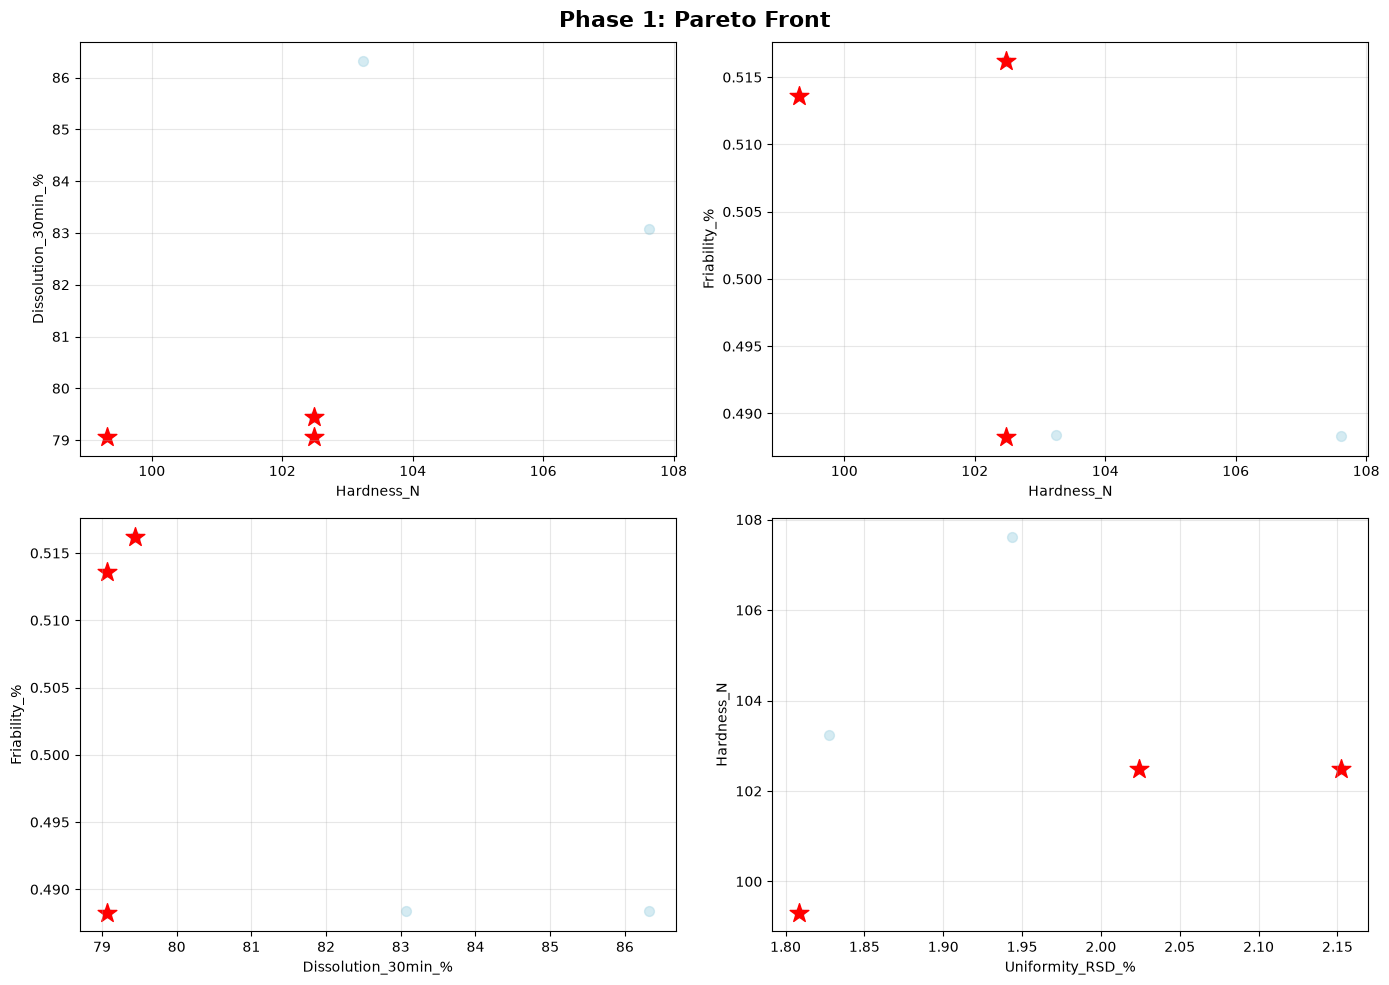

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Phase 1: Pareto Front', fontsize=16, fontweight='bold')

pairs = [('Hardness_N', 'Dissolution_30min_%'), ('Hardness_N', 'Friability_%'), 
         ('Dissolution_30min_%', 'Friability_%'), ('Uniformity_RSD_%', 'Hardness_N')]

for ax, (c1, c2) in zip(axes.flat, pairs):
    if c1 in space_def['cqa_names'] and c2 in space_def['cqa_names']:
        i1, i2 = space_def['cqa_names'].index(c1), space_def['cqa_names'].index(c2)
        ax.scatter(Y_final[:, i1], Y_final[:, i2], alpha=0.5, s=50, color='lightblue')
        ax.scatter(pareto_Y[:, i1], pareto_Y[:, i2], s=200, color='red', marker='*')
        ax.set_xlabel(c1); ax.set_ylabel(c2); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase1_pareto_front.png', dpi=300, bbox_inches='tight')
print('✓ Saved: phase1_pareto_front.png')
plt.show()


In [15]:
output = {
    'timestamp': datetime.now().isoformat(),
    'api_name': api_name,
    'n_experiments': len(X_final),
    'n_pareto': len(pareto_X),
    'gp_r2': float(r2_final),
    'pareto_cpp': pd.DataFrame(pareto_X, columns=space_def['cpp_names']).to_dict('records'),
    'pareto_cqa': pd.DataFrame(pareto_Y, columns=space_def['cqa_names']).to_dict('records'),
}

with open('phase1_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)

print('✓ Saved: phase1_results.json')
print('\n✅ Phase 1 Complete!')


✓ Saved: phase1_results.json

✅ Phase 1 Complete!
